Epoch [1/5] | VAE Loss: 79.00 | G Loss: 1.24 | D Loss: 0.51
Epoch [2/5] | VAE Loss: 84.54 | G Loss: 1.61 | D Loss: 0.43
Epoch [3/5] | VAE Loss: 77.08 | G Loss: 1.58 | D Loss: 0.55
Epoch [4/5] | VAE Loss: 77.27 | G Loss: 1.16 | D Loss: 0.47
Epoch [5/5] | VAE Loss: 72.77 | G Loss: 0.81 | D Loss: 0.54


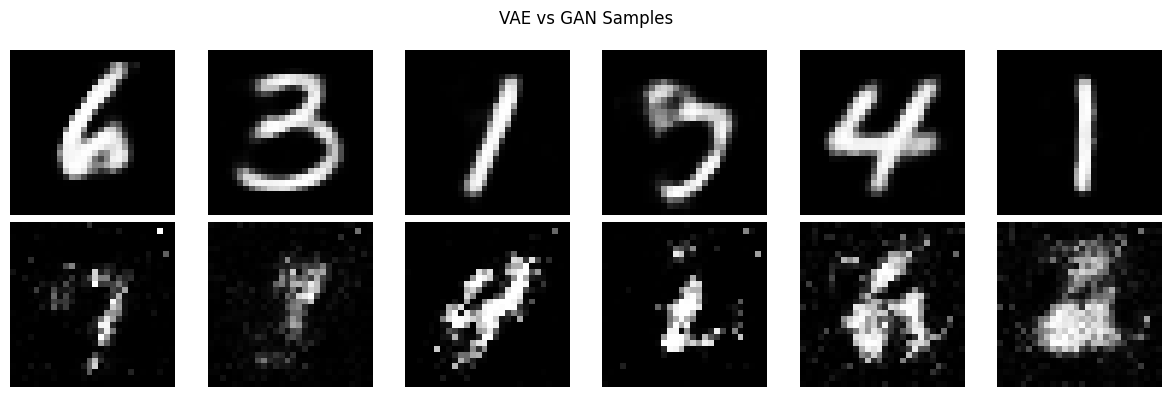

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs = 15

transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5))])
train_loader = DataLoader(datasets.MNIST(".",train=True,download=True,transform=transform),batch_size=64,shuffle=True)

class VAE(nn.Module):
  def __init__(self):
    super(VAE,self).__init__()
    self.encoder = nn.Sequential(nn.Linear(784,400), nn.ReLU())
    self.fc_mean = nn.Linear(400,20)
    self.fc_logvar = nn.Linear(400,20)
    self.decoder = nn.Sequential(nn.Linear(20,400),nn.ReLU(),nn.Linear(400,784),nn.Tanh())

  def reparametrize(self,mean,logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mean + eps * std

  def forward(self,x):
    h = self.encoder(x.view(-1,784))
    mean , logvar = self.fc_mean(h) , self.fc_logvar(h)
    z = self.reparametrize(mean,logvar)
    return self.decoder(z),mean,logvar

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
      return self.model(x.view(-1, 784))
# training
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

# Initialization
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
gen_optimizer = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(1, 6):
    vae.train()
    gen.train()
    disc.train()

    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        vae_optimizer.zero_grad()
        recon_batch, mean, logvar = vae(imgs)
        # Binary Cross Entropy + KL Divergence
        recon_loss = nn.functional.mse_loss(recon_batch, imgs.view(-1, 784), reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
        vae_loss = (recon_loss + kld_loss) / imgs.size(0)
        vae_loss.backward()
        vae_optimizer.step()

        # Train Discriminator
        disc_optimizer.zero_grad()
        z = torch.randn(imgs.size(0), 20).to(device)
        fake_imgs = gen(z)
        real_loss = criterion(disc(imgs), real_labels)
        fake_loss = criterion(disc(fake_imgs.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        disc_optimizer.step()

        # Train Generator
        gen_optimizer.zero_grad()
        g_loss = criterion(disc(fake_imgs), real_labels)
        g_loss.backward()
        gen_optimizer.step()

    print(f"Epoch [{epoch}/5] | VAE Loss: {vae_loss.item():.2f} | G Loss: {g_loss.item():.2f} | D Loss: {d_loss.item():.2f}")


# printing images for visualization
import matplotlib.pyplot as plt

vae.eval()
gen.eval()

with torch.no_grad():

    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)

    recon_imgs, _, _ = vae(imgs)
    recon_imgs = recon_imgs.cpu()

    z = torch.randn(6, 20).to(device)
    fake_imgs = gen(z).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):
    axes[0, i].imshow(recon_imgs[i].view(28, 28), cmap='gray')
    axes[0, i].axis('off')

for i in range(6):

    img = (fake_imgs[i] + 1) / 2

    axes[1, i].imshow(img.view(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("VAE", fontsize=12)
axes[1, 0].set_ylabel("GAN", fontsize=12)

plt.suptitle("VAE vs GAN Samples")
plt.tight_layout()

plt.show()